# Fuzzy k means 
## Comparison local vs Federated Approach

### 1. Dataset generation

In [1]:
import numpy as np
# dataset parameters
SEED = 1234
np.random.seed(SEED)

## parameters for data generation
cluster_centers = [[1, 1], [-1, -1], [1, -1], [0, 1]]
n_samples = 200
cluster_std = .5
space_dim = 2

nb_samples_per_nodes = [1, 1, 1, 1] # indicates how to sample data per node

In [2]:
from sklearn.datasets import make_blobs

X, labels_true = make_blobs(n_samples=n_samples,
                            centers=cluster_centers, cluster_std=cluster_std,
                           random_state=SEED)

In [3]:
to get best k : use K=argminXB

SyntaxError: invalid syntax (244387724.py, line 1)

In [4]:

class FuzzyKmeans:
    def __init__(self, k: int, mbship_param: float):

        assert mbship_param > 1, "cannot use fuzzykmeans for mbship_param = " + str(mbship_param)
        self._n_centroid = k
        self._mbship_param = mbship_param
        self._weights = []
        self._centroids = None
        self.U = None
    
    def partial_fit(self, X):
        if self._centroids is None:
            # initialize centroids
            idx = np.random.choice(X.shape[0], self._n_centroid, replace=False)
            self._centroids = X[idx]
        self._score = 0
        U = self.update_membership(X, self._centroids)
        self.U = U
        centroids, w, xb_score = self.compute_local_stats(X, U, self._centroids)
        self._centroids = centroids
        self._score = xb_score
        print("w",w)
        self._weights = w
        
    def predict(self, X):
  
        U = self.update_membership(X, self._centroids)
        labels = np.argmax(U, axis=1)
   
        return labels

    def score(self, X):
        """returns Xie Beni estimator
        XB=\frac{\sum_i\sum_j u_{ij}^m\|x_i-c_j\|^2} {N\min_{p\neq q}\|c_p-c_q\|^2}
        """
        # separation (min distance between centroids)

        um = self.U ** self._mbship_param
        xb_local = 0
        total_points = X.shape[0]
        min_dist = float('inf')
        C = self._centroids.shape[0] 
        for i in range(X.shape[0]):
            for j in range(C):
                dist_sq = np.linalg.norm(X[i] - self._centroids[j]) ** 2
                xb_local += um[i, j] * dist_sq


        min_dist = np.inf

        for i in range(C):
            for j in range(i+1, C):
                d = np.linalg.norm(self._centroids[i] - self._centroids[j])**2
                min_dist = min(min_dist, d)
        
        xb = xb_local / (len(X) * min_dist)
        return xb

    def update_membership(self, data, centroids):
        N = data.shape[0] # nb data
        C = centroids.shape[0]  # nb centroids
        U = np.zeros((N, C))

        
        for i in range(N):
            assigned = False
            for j in range(C):
                d_ij = np.linalg.norm(data[i] - centroids[j])
                if d_ij == 0:
                    U[i, :] = 0
                    U[i, j] = 1
                    assigned = True
                    break
            if assigned:
                continue
            for j in range(C):
                d_ij = np.linalg.norm(data[i] - centroids[j])
                sum_term = 0
                for k in range(C):
                    d_ik = np.linalg.norm(data[i] - centroids[k])
                    if d_ik == 0:
                        d_ik = 1e-6
                    sum_term += (d_ij / d_ik) ** (2 / (self._mbship_param - 1))
    
                U[i, j] = 1 / sum_term
        return U

    def compute_local_stats(self, data, U, centroids):
        C = centroids.shape[0]  # nb centroids
        um = U ** self._mbship_param
    
        # Local centroid
        c_local = (um.T @ data) / np.sum(um.T, axis=1, keepdims=True)
    
        # Weights for aggregation
        weights = np.sum(um, axis=0)
        
        # XB numerator contribution
        xb_local = 0
        for i in range(data.shape[0]):
            for j in range(C):
                dist_sq = np.linalg.norm(data[i] - c_local[j]) ** 2
                xb_local += um[i, j] * dist_sq
    
        return c_local, weights,  xb_local

<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_873/2461283409.py:33: SyntaxWarning: invalid escape sequence '\s'
  """returns Xie Beni estimator


In [5]:
fuzzy_k_means = FuzzyKmeans(4, 2)
print(fuzzy_k_means._centroids)
for _ in range(10):
    fuzzy_k_means.partial_fit(X)
print(fuzzy_k_means._centroids)

None
w [45.07462475 13.27932789 23.16868007 29.12960737]
w [43.76373142 16.64120294 32.49814007 27.3549026 ]
w [41.9408836  18.4142196  34.24557579 28.23058029]
w [39.83015333 19.86195715 34.73752263 29.21115703]
w [37.75746708 21.44789961 34.98270323 30.20112113]
w [35.87665015 23.36055246 35.13191905 31.15751302]
w [34.30263442 25.53224164 35.2091552  32.04578177]
w [33.08304983 27.70668023 35.22013223 32.82797392]
w [32.17001245 29.60232451 35.17806603 33.47164986]
w [31.46877177 31.07039782 35.10577813 33.96515731]
[[ 0.13063719  1.01535586]
 [ 1.14459803  0.86631969]
 [-1.02231785 -1.05846607]
 [ 1.01210397 -0.94615994]]


In [33]:
cluster_centers

[[1, 1], [-1, -1], [1, -1], [0, 1]]

In [94]:
fuzzy_k_means.partial_fit(X)

w [29.09710889 34.7026492  34.45254465 35.09133615]


In [88]:
print(fuzzy_k_means._centroids)

[[ 0.31518358 -0.0050059 ]
 [ 0.31518358 -0.0050059 ]
 [ 0.31518358 -0.0050059 ]
 [ 0.31518358 -0.0050059 ]]


In [40]:
X[0] - fuzzy_k_means._centroids[0]

array([-2.2023762 , -2.32713822])

In [95]:
fuzzy_k_means.predict(X)

array([2, 2, 2, 0, 1, 2, 1, 2, 1, 2, 3, 2, 1, 0, 3, 0, 0, 1, 3, 0, 0, 3,
       3, 3, 1, 2, 0, 0, 3, 2, 2, 1, 3, 0, 1, 1, 1, 0, 3, 1, 0, 2, 2, 3,
       3, 3, 3, 2, 1, 0, 3, 0, 0, 3, 2, 0, 0, 3, 1, 1, 1, 2, 3, 0, 0, 0,
       0, 1, 2, 1, 0, 1, 0, 0, 3, 0, 0, 3, 1, 2, 1, 0, 3, 2, 1, 1, 0, 2,
       0, 0, 3, 3, 0, 1, 3, 0, 3, 3, 1, 2, 0, 2, 2, 1, 0, 2, 0, 3, 3, 2,
       3, 1, 1, 1, 1, 2, 3, 1, 3, 3, 2, 0, 3, 1, 1, 0, 2, 2, 1, 2, 3, 1,
       3, 3, 2, 2, 2, 3, 2, 3, 2, 0, 2, 3, 3, 1, 2, 0, 2, 2, 0, 0, 2, 2,
       1, 0, 1, 3, 1, 1, 3, 2, 3, 2, 3, 3, 1, 3, 2, 1, 0, 1, 2, 3, 1, 3,
       2, 1, 1, 2, 3, 0, 0, 0, 2, 3, 3, 2, 1, 2, 1, 1, 0, 0, 3, 2, 2, 3,
       1, 3])

In [6]:
batch_size = 20
n_rounds = 5
n_epochs = 3
n_batch = int(np.ceil(X.shape[0] / batch_size))  # compute number of different batch+1 in one epoch
fmbk_local = FuzzyKmeans(4, 2.)
for r in range(n_rounds):
    for epoch in range(n_epochs):
        np.random.shuffle(X)
        for i_batch in range(n_batch):
            
            if i_batch == n_batch -1 :
                #last batch size
                fmbk_local.partial_fit(X[i_batch*batch_size:])
            else:

                fmbk_local.partial_fit(X[i_batch*batch_size:(i_batch+1)*batch_size]) 



w [2.48777629 2.31745571 2.55071726 2.75676502]
w [2.31518551 4.50094547 1.36555338 1.82655239]
w [3.88126024 1.72253404 1.95817658 1.08624692]
w [2.84160616 1.89498539 2.08514489 1.81578858]
w [3.00708039 2.75095707 2.23523402 3.76170802]
w [4.20577792 2.99953785 1.59464191 3.62542278]
w [0.915362   3.77669213 4.25303332 3.67024786]
w [2.6559738  4.42063552 3.28959478 1.78309248]
w [6.13690767 3.21626751 1.62526408 2.68504295]
w [4.91989939 2.44026272 1.36815368 3.72266264]
w [2.96639777 4.60635764 4.5821012  1.94255942]
w [4.33806968 3.18370295 1.58522135 2.65979579]
w [1.06022093 5.3335283  4.21115889 1.63684462]
w [4.00775906 2.93905419 4.10290928 1.65896582]
w [5.89375402 2.19478675 2.10331762 2.60768417]
w [4.25869158 6.73950173 2.33147241 0.68001396]
w [3.7969782  2.0176296  1.97559165 3.62220094]
w [4.57745556 2.37169013 1.70551594 4.46418668]
w [0.8306724  2.31839678 3.93978614 3.46472286]
w [1.90083907 0.91935777 4.94716174 4.21234347]
w [4.0284892  3.02589529 1.92160711 3.02

In [97]:
preds = fuzzy_k_means.predict(X)
preds

array([2, 1, 1, 2, 1, 0, 1, 1, 2, 3, 3, 1, 0, 1, 1, 2, 1, 2, 0, 0, 1, 1,
       1, 0, 3, 1, 3, 3, 3, 1, 3, 2, 0, 1, 2, 0, 1, 0, 2, 2, 3, 3, 0, 1,
       2, 3, 3, 3, 0, 0, 3, 2, 2, 3, 2, 0, 2, 3, 2, 3, 0, 2, 2, 2, 2, 3,
       2, 0, 0, 3, 0, 1, 3, 0, 0, 3, 0, 3, 3, 3, 1, 2, 3, 2, 2, 1, 1, 1,
       2, 0, 0, 0, 2, 3, 0, 3, 0, 2, 0, 2, 0, 2, 1, 3, 3, 1, 0, 1, 0, 1,
       3, 3, 3, 0, 1, 2, 2, 0, 3, 3, 1, 1, 2, 1, 3, 0, 1, 3, 0, 0, 1, 2,
       1, 2, 2, 3, 1, 2, 2, 1, 1, 1, 1, 3, 3, 0, 1, 1, 2, 1, 1, 2, 0, 1,
       0, 0, 2, 3, 3, 2, 0, 1, 2, 2, 3, 0, 3, 0, 3, 3, 3, 0, 0, 3, 1, 2,
       1, 3, 3, 3, 2, 3, 3, 2, 0, 0, 0, 0, 2, 2, 2, 3, 2, 2, 0, 1, 1, 3,
       2, 1])

Text(0.5, 1.0, 'Local MiniBatchFuzzykMeans')

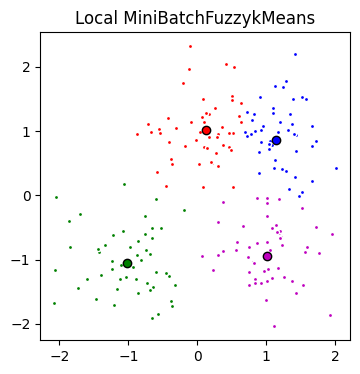

In [7]:
import matplotlib.pyplot as plt
colors = ['r', 'b', 'g', 'm']

fig = plt.figure(figsize=(4, 4))

cluster_center = fuzzy_k_means._centroids
preds = fuzzy_k_means.predict(X)
n_clusters = 4

for k, col in zip(range(n_clusters), colors):
    my_members = preds == k
    cluster_center = fuzzy_k_means._centroids[k]
    plt.plot(X[my_members, 0], X[my_members, 1], 'w',
            markerfacecolor=col, marker='.')
    plt.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,
            markeredgecolor='k', markersize=6)
plt.title('Local MiniBatchFuzzykMeans')

In [72]:
cluster_center 

array([[-1.01758317, -1.08276943],
       [ 1.06252551,  1.04149752],
       [ 0.00636407,  0.85906258],
       [ 1.04349263, -0.90415884]])

In [8]:
from typing import List, Tuple, Dict
def generate_federated_clustering_dataset(dataset: np.ndarray,
                                          labels: np.ndarray,
                                          nodes_id: List[str],
                                          nb_samples_per_nodes: list,
                                         random_seed:int=None) -> Tuple[Dict[str, np.ndarray],
                                                                        Dict[str, np.ndarray]]:
    """
    Split classification / clustering dataset into several nodes
    
    Args:
    
    Returns:
    federated_dataset (Dict[str, np.ndarray]): a dictionary containing node id defined in argument
    `nodes_id` mapping their respective training input datasets
    federated_labels (Dict[str, np.ndarray]]): a dictionary containing node id defined in argument
    `nodes_id` mapping their respective training label datasets (from which cluster point in 
    `federated_dataset` returned argument belongs to)
    """
    
    assert len(nodes_id) == len(nb_samples_per_nodes), "len(nodes_id) must equal len(nb_samples_per_nodes)"
    nb_samples_per_nodes = np.array(nb_samples_per_nodes)
    w_sum_nodes = nb_samples_per_nodes / nb_samples_per_nodes.sum()
    
    nb_samples = labels.shape[0]
    w_sum_nodes *= nb_samples
    
    print(w_sum_nodes)
    
        
    all_X, all_labels = {}, {}
    labels_tags = np.unique(labels)
    n_labels = len(labels_tags)
        
    idx_pointer = np.zeros((n_labels))
    
    # this part is for splitting equally cluster for nodes
    # making sure every clients have the same number of labels
    for i,idx in enumerate(w_sum_nodes):
        # iterates over node"
        for i_lab, lab in enumerate(labels_tags):
            label_idx = lab == labels

            idx1 = int(idx_pointer[i_lab])
            idx2 = idx1 + int(np.floor(idx / n_labels))

            #idx1_sample, idx2_sample = int(np.floor(idx / n_labels)), int(np.floor(idx / n_labels))
            sampled_X, sampled_labels = (dataset[label_idx][idx1: idx2],
                                            labels[label_idx][idx1: idx2])
            if nodes_id[i] not in all_X.keys():
                all_X[nodes_id[i]] = sampled_X
                all_labels[nodes_id[i]] = sampled_labels
            else:
                all_X[nodes_id[i]] = np.concatenate([all_X[nodes_id[i]], sampled_X], axis=0)
                all_labels[nodes_id[i]] = np.concatenate([all_labels[nodes_id[i]], sampled_labels], axis=0)
            idx1 = idx2
            idx_pointer[i_lab] = idx1
        
    
    
    # this part is for splitting remaining points into 
    # nodes datasets (that could occur if data points in original dataset
    # divided by number of clients is not equal to an integer):
    # as a consequence, datasets among clients will be uneven
    remaining_data_pts = dataset.shape[0] - idx_pointer.sum()
    print("remaining : ", remaining_data_pts, " points")
    for i,idx in enumerate(w_sum_nodes):

        if all_labels[nodes_id[i]].shape[0] < idx:
            diff = np.abs(all_labels[nodes_id[i]].shape[0] - idx)
            diff = np.ceil(diff)
            #diff = nb_samples - idx_pointer.sum()
            
            while diff> 0 and remaining_data_pts >0:
                for i_lab, lab in enumerate(labels_tags):

                    label_idx = lab == labels
                    idx1 = int(idx_pointer[i_lab])
                    #maximum = int(np.ceil(labels[label_idx].shape[0] / len(nodes_id)))
                    maximum = int(labels[label_idx].shape[0])

                    if idx1  < maximum :


                        all_X[nodes_id[i]] = np.concatenate([all_X[nodes_id[i]],
                                                             dataset[label_idx][idx1].reshape(1,-1)],
                                                            axis=0)

                        all_labels[nodes_id[i]] = np.concatenate([all_labels[nodes_id[i]],
                                                                  np.array([labels[label_idx][idx1]])], axis=0)
                        diff -= 1
                        idx1 += 1
                        remaining_data_pts -= 1
                        idx_pointer[i_lab] = idx1
                        if diff == 0:
                            break
                    else:
                        continue
                print("added remaining point(s) to node ", nodes_id[i])
                
        print(idx_pointer)
        
        # randomly permute index of dataset of each node
        if random_seed is not None:
            rng = np.random.RandomState(random_seed)
            permuted_idx = rng.permutation(all_labels[nodes_id[i]].shape[0])
            all_X[nodes_id[i]]  = all_X[nodes_id[i]] [permuted_idx]
            all_labels[nodes_id[i]] = all_labels[nodes_id[i]][permuted_idx]
    return all_X, all_labels

In [9]:
nodes_id = ["alice", "bob", "charlie", "danny"]
n_rounds = 200
distance_metric = "euclidean"
nb_samples_per_nodes = [1, 1, 1, 1] # indicates how to sample data per node -> here nodes are sampled uniformly

federated_dataset, federated_labels = generate_federated_clustering_dataset(X,
                                                                            labels_true,
                                                                            nodes_id,
                                                                            nb_samples_per_nodes,
                                                                            random_seed=SEED
                                                                           )

[50. 50. 50. 50.]
remaining :  8.0  points
added remaining point(s) to node  alice
[49. 49. 48. 48.]
added remaining point(s) to node  bob
[50. 50. 48. 48.]
added remaining point(s) to node  charlie
[50. 50. 49. 49.]
added remaining point(s) to node  danny
[50. 50. 50. 50.]


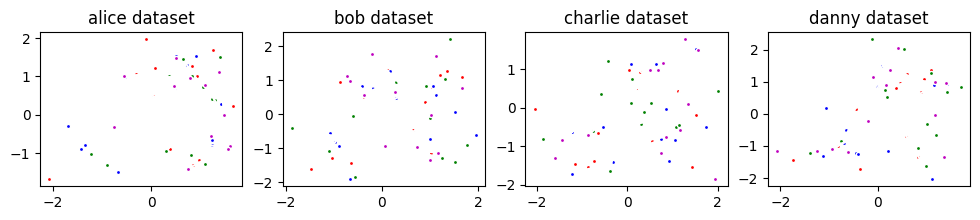

In [10]:
plt.figure(figsize=(12, 2))
n_clients = len(nodes_id)
for n_cli, cli in enumerate(nodes_id):
    plt.subplot(1, n_clients, n_cli+1)
    for k, col in zip(range(n_clusters), colors):
        my_members = federated_labels[cli] == k
        
        plt.plot(federated_dataset[cli][my_members, 0], federated_dataset[cli][my_members, 1], 'w',
                markerfacecolor=col, marker='.')
        
        plt.title(f"{cli} dataset")

In [12]:
nodes = {}

for n in nodes_id:
    fmbk = FuzzyKmeans(4, 2)
    nodes[n] = {'model' : fmbk, 'loss': []}

In [43]:
fmbk.partial_fit(X)
fmbk.score

w [14.14034548 13.28874889 16.28718092 15.98839788]


<bound method FuzzyKmeans.score of <__main__.FuzzyKmeans object at 0x7f6ccb970350>>

In [15]:
from sklearn.metrics.pairwise import pairwise_distances_argmin, pairwise_distances
from scipy.optimize import linear_sum_assignment

n_rounds = 200

# federated learning
for r in range(n_rounds):
    for n in nodes_id:
        n_batch = int(np.ceil(federated_dataset[n].shape[0] / batch_size))  # compute number of batch+1 to use over one epoch
        for epoch in range(n_epochs):
            np.random.shuffle(federated_dataset[n])
            for i_batch in range(n_batch):

                if i_batch == n_batch - 1:
                    # last batch size
                    nodes[n]['model'].partial_fit(federated_dataset[n][i_batch*batch_size:]) 
                    score= nodes[n]['model'].score(federated_dataset[n][i_batch*batch_size:])
                    nodes[n]['loss'].append(score)
                else:
                    nodes[n]['model'].partial_fit(federated_dataset[n][i_batch*batch_size:(i_batch+1)*batch_size]) 
                    score = nodes[n]['model'].score(federated_dataset[n][i_batch*batch_size:(i_batch+1)*batch_size])
                    nodes[n]['loss'].append(score)


    # federated agg
    # recognize order
    new_centroids = np.zeros_like(nodes[nodes_id[0]]['model']._centroids)
    weights = [nodes[n]['model']._weights for n in nodes_id]
    total_weights = np.sum(weights, axis=0)
    
    ref_centroids = nodes[nodes_id[0]]["model"]._centroids
    for i, n in enumerate(nodes_id):
        comp_centroids = nodes[n]["model"]._centroids
        # Cost matrix between reference and current client's centroids
        cost = pairwise_distances(ref_centroids, comp_centroids)
        # Optimal one-to-one assignment
        row_ind, col_ind = linear_sum_assignment(cost)
        if len(nodes_id) > 1:
                for ref_idx, comp_idx in zip(row_ind, col_ind):
                        new_centroids[ref_idx] += (
                            nodes[n]["model"]._weights[comp_idx]
                            * comp_centroids[comp_idx]
                        )

   
    # Aggregate centroids
        #for j in range(4): # nb clusters

         #   new_centroids[j] += nodes[n]['model']._weights[order][j] * nodes[n]['model']._centroids[order][j]
    for j in range(new_centroids.shape[0]): # nb_clusters
        new_centroids[j] /= total_weights[j]
    
    
    for n in nodes_id:
        nodes[n]['model']._centroids = new_centroids
    print('round', r, 'xb score', sum(nodes[n]['loss'][-1] for n in nodes_id))
    

w [1.63569631 1.87603843 2.01700769 5.25200637]
w [1.36534643 4.43936251 2.15071611 5.36067358]
w [2.84487456 2.64508256 0.47692423 0.48067761]
w [2.06041963 5.66317973 2.76664842 3.01002114]
w [2.38352805 4.37960286 0.85480466 5.6695599 ]
w [0.33720088 0.34628429 2.05908127 2.95580094]
w [3.95856003 1.93845729 2.92915433 0.9336954 ]
w [2.9838298  5.08783031 1.17838684 2.02520258]
w [1.77362356 0.24882722 1.62716885 2.19224875]
w [2.34561572 3.65781618 3.41844089 2.271621  ]
w [2.62381725 1.36738877 2.21890864 5.21109847]
w [2.21123992 1.63982591 0.72694118 1.81235063]
w [4.19456617 3.2577799  1.1290856  3.06077032]
w [1.90900572 4.43288641 4.06923081 3.9232739 ]
w [2.23406107 0.14617896 2.02258348 3.05881086]
w [3.10225476 2.20980442 3.50979432 4.08134696]
w [3.81707664 2.93369958 1.74482454 4.82987118]
w [1.2555036  1.75750203 2.24468743 1.14061767]
w [3.06159259 3.30894277 4.15053298 0.78864574]
w [3.15865245 3.63139602 0.9988175  3.04416204]
w [0.44941011 3.05066095 2.21703857 0.18

In [132]:
cluster

3

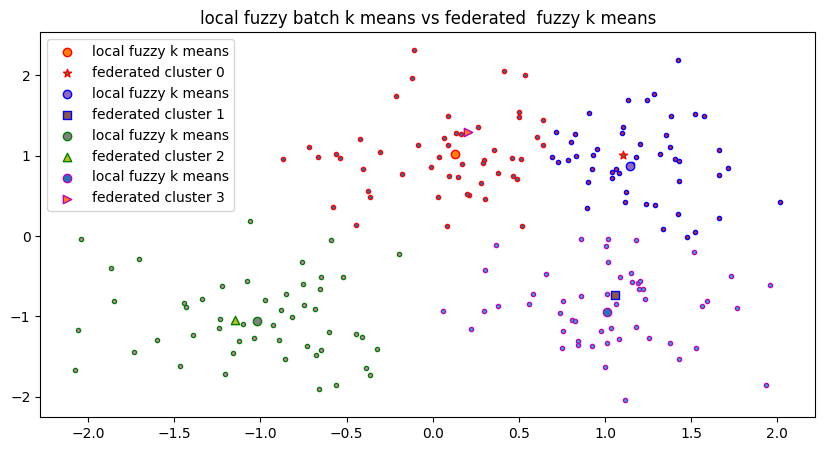

In [41]:
plt.figure(figsize=(10,5))
markers = ["*", "s", "^", ">"]
# display locally trained fuzzy k means
for k, col in zip(range(n_clusters), colors):
    my_members = preds == k
    cluster_center = fuzzy_k_means._centroids[k]
    plt.scatter(X[my_members, 0], X[my_members, 1], 
            edgecolor=col, marker='.')
    plt.scatter(cluster_center[0], cluster_center[1], marker='o', edgecolor=col,
              label="local fuzzy k means")
    
    #for i, n in enumerate(nodes.keys()):
    n = nodes_id[0]
    plt.scatter(nodes[n]['model']._centroids[k,0],
            nodes[n]['model']._centroids[k,1],
             marker=markers[k],  label="federated cluster " + str(k) , edgecolor=col, )
    
    plt.title("local fuzzy batch k means vs federated  fuzzy k means")
plt.legend()

In [128]:
nodes[n]['model']._centroids

array([[ 0.85251361,  1.85042582],
       [ 1.22529577,  2.04991763],
       [-2.07517341, -2.23975284],
       [ 2.21335777, -1.95081212]])

In [119]:
nodes['danny']['model']._centroids

array([[ 1.09424573,  0.77950692],
       [ 0.10465751,  0.89780363],
       [-0.94376477, -1.06623147],
       [ 1.11577731, -0.94931545]])

In [68]:
weights = [nodes[n]['model']._weights for n in nodes_id]

# Aggregate centroids
new_centroids = np.zeros_like(nodes[nodes_id[0]]['model']._centroids)
total_weights = np.sum(weights, axis=0)

In [69]:
weights

[array([1.88179207, 1.3406621 , 0.8657123 , 1.05140529]),
 array([1.02352931, 2.33256672, 0.49576723, 1.3903948 ]),
 array([0.84564081, 2.33887644, 1.49812346, 2.65148329]),
 array([2.9497611 , 2.06001471, 0.40447782, 0.53304404])]

In [49]:
total_weights

array([11.79904442,  8.24005886,  1.61791128,  2.13217614])

In [62]:


for i, n in enumerate(nodes_id):
    ref_order_model = nodes[nodes_id
                            [0]]['model']
    if len(nodes_id) > 1:
        comp_model = nodes[n]['model']
        order = pairwise_distances_argmin(ref_order_model._centroids,
                                          comp_model._centroids,
                                             metric="euclidean")

In [67]:
local_centroids

[array([[2.52725858, 2.52725858],
        [1.99187304, 1.99187304]]),
 array([[9.00812696, 9.00812696],
        [8.47274142, 8.47274142]])]

In [71]:




for j in range(4): # nb clusters
    for k, n in enumerate(nodes_id):
        new_centroids[j] += nodes[n]['model']._weights[j] * nodes[n]['model']._centroids[j]
    new_centroids[j] /= total_weights[j]

centroids = new_centroids

In [72]:
centroids

array([[ 0.64152237,  0.88101935],
       [ 0.56252221, -0.93120894],
       [ 0.23089702,  0.51122954],
       [-0.11306204, -0.69339769]])

In [73]:
order

array([2, 1, 3, 0])

In [ ]:
!pip install numpy 
# federated fuzzy means

import numpy as np

# Parameters
C = 2  # nb of centroid
m = 2.0
# m: mbship param, m=1 -> classical kmeans (:!\ not defined 
# m belongs [1.5;3]
# m small: clusters are tight and crisp
# m high:  clusters overlaps more
rounds = 20

# Simulated clients
client_data = [
    np.array([[1,1], [2,2], [3,3]], dtype=float),
    np.array([[8,8], [9,9], [10,10]], dtype=float)
]

# Initialize centroids
centroids = np.random.rand(C, 2)


class FuzzyKmeans:
    def __init__(self, k: int, mbship_param: float):
        self._n_centroid = k
        self._mbship_param = mbship_param
        self.weights = None
        self._centroids = np.random.rand(k, 2)
    
    def partial_fit(self, X):
        U = update_membership(X, self._centroids)

        c_local, w_local, xb_local = compute_local_stats(
            data, U, self._centroids
        )

        self._centroids = c_local
        self.weights = w_local
        xb_total += xb_local
        
        
    def predict(self, X):
        C = self._centroids.shape[0] 
        prediction = np.zeros(X.shape[0], C)
        
        for i in range(C):
            prediction[i,:] = np.linalg.norm(X - self._centroids[j])

        prediction = np.argmin(prediction)

        return prediction

    def score(self, X):
        pass

    def update_membership(self, data, centroids):
        N = data.shape[0] # nb data
        C = centroids.shape[0]  # nb centroids
        U = np.zeros((N, C))
    
        for i in range(N):
            for j in range(C):
                d_ij = np.linalg.norm(data[i] - centroids[j])
                if d_ij == 0:
                    U[i, :] = 0
                    U[i, j] = 1
                    continue
    
                sum_term = 0
                for k in range(C):
                    d_ik = np.linalg.norm(data[i] - centroids[k])
                    if d_ik == 0:
                        d_ik = 1e-6
                    sum_term += (d_ij / d_ik) ** (2 / (m - 1))
    
                U[i, j] = 1 / sum_term
        return U

    def compute_local_stats(self, data, U, centroids):
        um = U ** m
    
        # Local centroid
        c_local = (um.T @ data) / np.sum(um.T, axis=1, keepdims=True)
    
        # Weights for aggregation
        weights = np.sum(um, axis=0)
    
        # XB numerator contribution
        xb_local = 0
        for i in range(data.shape[0]):
            for j in range(self._n_centroid):
                dist_sq = np.linalg.norm(data[i] - centroids[j]) ** 2
                xb_local += um[i, j] * dist_sq
    
        return c_local, weights, xb_local
        
def update_membership(data, centroids):
    N = data.shape[0]
    C = centroids.shape[0]
    U = np.zeros((N, C))

    for i in range(N):
        for j in range(C):
            d_ij = np.linalg.norm(data[i] - centroids[j])
            if d_ij == 0:
                U[i, :] = 0
                U[i, j] = 1
                continue

            sum_term = 0
            for k in range(C):
                d_ik = np.linalg.norm(data[i] - centroids[k])
                if d_ik == 0:
                    d_ik = 1e-6
                sum_term += (d_ij / d_ik) ** (2 / (m - 1))

            U[i, j] = 1 / sum_term
    return U

def compute_local_stats(data, U, centroids):
    um = U ** m

    # Local centroid
    c_local = (um.T @ data) / np.sum(um.T, axis=1, keepdims=True)

    # Weights for aggregation
    weights = np.sum(um, axis=0)

    # XB numerator contribution
    xb_local = 0
    for i in range(data.shape[0]):
        for j in range(C):
            dist_sq = np.linalg.norm(data[i] - centroids[j]) ** 2
            xb_local += um[i, j] * dist_sq

    return c_local, weights, xb_local, data.shape[0]

def compute_xb(centroids, xb_numerator, total_points):
    # separation (min distance between centroids)
    min_dist = float('inf')
    for i in range(C):
        for j in range(i + 1, C):
            dist = np.linalg.norm(centroids[i] - centroids[j]) ** 2
            if dist < min_dist:
                min_dist = dist

    return xb_numerator / (total_points * min_dist)

# Federated loop
for r in range(rounds):
    local_centroids = []
    weights = []
    xb_total = 0
    total_points = 0

    for data in client_data:
        U = update_membership(data, centroids)

        c_local, w_local, xb_local, n_local = compute_local_stats(
            data, U, centroids
        )

        local_centroids.append(c_local)
        weights.append(w_local)
        xb_total += xb_local
        total_points += n_local

    # Aggregate centroids
    new_centroids = np.zeros_like(centroids)
    total_weights = np.sum(weights, axis=0)

    for j in range(C):
        for k in range(len(client_data)):
            new_centroids[j] += weights[k][j] * local_centroids[k][j]
        new_centroids[j] /= total_weights[j]

    centroids = new_centroids

    # Compute XB index
    xb = compute_xb(centroids, xb_total, total_points)
    print(f"Round {r+1}, XB Index: {xb:.4f}")

print("\nFinal Centroids:\n", centroids)